# 05b — Per-sensor track crossings for PIXELAV: the calorimeter step-energy method

> **Method 2 of 2 for building PIXELAV crossings — the calorimeter route — co-equal with**
> **[05a](05a_pixelav_inputs_tracker.ipynb), not a fallback.** With `enableDetailedShowerMode`,
> every Geant4 step deposit becomes a `CaloHitContribution` (global position + energy + time +
> producing-particle link); crossings are reconstructed by **time-ordering** the steps of each
> (particle, sensor) and splitting them into per-layer runs. This route gives what 05a cannot — the
> **entry-face** position (earliest-in-time step) and the full **step-level deposit** inside the
> sensor — at the cost of momentum: the `CaloHitContribution` schema has none, so each crossing
> inherits the producing particle's *production* momentum (fine for the hard, near-straight tracks
> that dominate; wrong for a particle that has radiated to low energy by a deep layer).

The same silicon can be read out two ways, and CALOMAPS uses **both**:

| | Calorimeter readout (this notebook, 05b) | Tracker readout ([05a](05a_pixelav_inputs_tracker.ipynb)) |
|---|---|---|
| EDM4hep object | `SimCalorimeterHit` + `CaloHitContribution` | `SimTrackerHit` |
| Position | **entry-face** + every step inside the sensor | energy-weighted (≈ mid-plane) |
| Momentum | production only (no per-step) | **real per-crossing momentum** |
| Step-level deposit | **yes** (per-step dE) | combined per crossing |
| Converter variant | **A** (`build_segments_A`) | C (`build_segments_C`) |
| Reach for it when | only a calo readout exists; entry-face / step detail needed | the βγ / dE/dx regime matters |

The sensitive detector is a passive observer — it changes only *what is recorded*, not the physics;
the calorimeter and tracker runs use the same gun, physics list and seed, so the shower is identical.
See [**05a §2b**](05a_pixelav_inputs_tracker.ipynb) for the full side-by-side, the primary-vs-delta
(born-outside vs born-inside) distinction, and how each readout feeds PIXELAV.

## 1. What PIXELAV consumes — and why energy deposits are *not* it

PIXELAV is **not** an energy-deposit consumer. Given a charged track's geometry and kinematics
it **generates its own ionization internally** (Bichsel dE/dx + Landau straggling + delta rays),
then drifts, diffuses and traps the electron–hole pairs through the sensor's electric and
magnetic fields to produce the induced pixel signal. So we feed it **track segments**, never the
Geant4 energy deposits. It comes in two stages:

| Stage | What it is | Who provides it |
|-------|------------|-----------------|
| **A** — sensor / field model | 3-D E-field map, thickness, bias/depletion V, temperature, mobility/Hall model, B-field, pixel pitch, radiation-damage params | hand-authored **per sensor**, external to our sim |
| **B** — per-track event input | **one record per charged-track crossing of a sensor** | **this converter** |

A Stage-B record, in the sensor's **local** frame, is:
- the **local entry point** `(u, v)` on the entry face — `u` across the pixel pitch, `v` along the cylinder-z axis;
- the **direction cosines** `cot α = p_u/p_w`, `cot β = p_v/p_w`, where `w` is the sensor-normal (depth) axis;
- the **momentum magnitude** `|p|` (sets the βγ / dE/dx regime: a MIP vs a soft electron);
- the **particle type**.

PIXELAV transports the straight track across the **full depletion depth itself**, so it works
from an *entry point + direction*, not a separately stored exit. In its standard mode it even
**samples the sub-pixel entry itself** (randomly over the central 3×3 pixels — its job is to scan
that position dependence into a *template*, see §7a), so from us it reads only the **direction,
momentum and type**; the entry point we provide rides along as a label unless we patch PIXELAV to
inject our truth. **Why the whole-track endpoints from notebook 04 are not enough:** an `MCParticle`'s `vertex`/`endpoint` bracket its entire
trajectory — birth to final stop, possibly several sensors and tungsten plates away. PIXELAV
works **one sensor at a time**. The per-crossing geometry lives in the per-step
`CaloHitContribution` truth, which is what we surface and reshape here.

**Does PIXELAV's result have to "match" Geant4? No — and that is the point.** If PIXELAV propagates the track through the sensor by itself, a fair question is whether the particle it produces at the far face agrees with what Geant4 says. It does **not** produce an outgoing particle to compare against Geant4 — it produces the **induced pixel charge cluster**
(the detector's electrical response). The two simulations divide the labour cleanly:
- **The handoff is only the track kinematics** — entry point, direction, momentum, type. That is
  the *same physical track* in both, so there is nothing to reconcile there.
- **The charge physics is deliberately PIXELAV's, at higher fidelity.** Geant4 gives us a coarse
  ionisation deposit; PIXELAV regenerates the ionisation from scratch (Bichsel cross sections +
  delta rays) and then does the realistic 3-D drift/diffusion/Lorentz transport through the
  measured field that Geant4's calorimeter model never does. So the deposited charge and the
  cluster shape will *not* be identical to Geant4 — by design, because PIXELAV is the better
  sensor model.
- **A 320 µm sensor is thin**, so the track barely bends or loses energy crossing it: PIXELAV's
  straight-line assumption is a good approximation, and entry direction ≈ exit direction. (Geant4
  may record slight curvature within the sensor — the few steps of §3 — which we average over.)
- **As a consistency check**, the right comparison is the *total ionisation*: PIXELAV's
  number of e–h pairs × 3.68 eV versus Geant4's deposited energy for the same crossing — these
  should agree to within the Landau/Vavilov fluctuations and the dE/dx-model differences (tens of
  %), not exactly. Disagreement beyond that would flag a units/geometry error in the handoff, not
  a physics inconsistency.

**Does the energy-loss difference compound through the shower the deeper we go? No — the two
simulations are not chained.** Geant4 grows the *entire* shower by itself, using its own energy
loss everywhere, and that history is complete and self-consistent before PIXELAV runs. PIXELAV is
then applied **independently, once per crossing**: it takes Geant4's kinematics at that crossing
as fixed input and returns only the pixel cluster — it never advances the particle to the next
layer and never feeds back, so there is no chain along which a discrepancy could accumulate. And
even per crossing the difference is physically negligible: the shower develops in the thick
**tungsten** (each plate ~0.7–1.4 X₀), while the silicon is a 0.32 mm **sampling** layer where a
track drops only a MIP-level ~85 keV — the Si sees ~1.5% of the shower energy in total (the
sampling fraction from nb01). Which dE/dx model is used in that thin Si is a sub-permille
perturbation on the particle's energy and is irrelevant to the W-driven shower. So Geant4 owns
the (well-validated) shower physics; PIXELAV upgrades only the per-sensor charge response.

## 2. The enabling change — `enableDetailedShowerMode`

The per-step truth is **not written by default.** Each `CaloHitContribution` *can* carry a
`stepPosition`, `PDG` and `stepLength`, but the EDM4hep writer only fills them when the
calorimeter sensitive detector runs in **`DETAILED_MODE` (`HitCreationMode = 2`)**. In the
default `SIMPLE_MODE` those fields are silently left at zero — a contribution then carries only
its deposited energy and a link to the producing `MCParticle`.

The one steering line that flips this, in
[`sim/run_sim_fullcascade.py`](../sim/run_sim_fullcascade.py), is:

```python
SIM.enableDetailedShowerMode = True
```

(It is a *different* knob from `SIM.part.enableDetailedHitsAndParticleInfo`, which does **not**
populate `stepPosition`.) This stays entirely on the **EDM4hep** path — the same format
notebooks 01–04 use — so it composes with the full-cascade settings from notebook 04
(`keepAllParticles`, `userParticleHandler = ""`). The sample here is the same 50 GeV photon,
same random seed (424242) as notebook 04, regenerated with detailed mode on, so the cascade is
identical and only the per-step truth is added.

**To regenerate** (on EAF, Key4hep `2026-04-08` for the full cascade):

```bash
ddsim --compactFile SiD_TestBeam.xml --steeringFile ../sim/run_sim_fullcascade.py \
      --numberOfEvents 1 --random.seed 424242
python ../analysis/extract_cascade.py     # EDM4hep -> models/*.npz (now incl. the contribution arrays)
```

In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

HOME = os.environ.get("CALOMAPS_HOME") or os.path.abspath("..")
sys.path.insert(0, os.path.join(HOME, "analysis"))
import pixelav_converter as pc   # the converter is the source of truth; we call it directly below

def _find(name):
    for p in [os.path.join(HOME, "models", name), os.path.join("..", "models", name), os.path.join("models", name)]:
        if os.path.exists(p): return p
    raise FileNotFoundError(f"{name} not found - run analysis/extract_cascade.py first.")

d = np.load(_find("fullcascade_gamma50_1evt.npz"), allow_pickle=True)
# per-step contribution truth (populated only with detailed mode)
cmc, ct, cE, cpdg = d["cmc"], d["ctime"], d["cE"], d["cpdg"]
csx, csy, csz = d["csx"], d["csy"], d["csz"]                       # global step position (mm)
pdg, px, py, pz = d["pdg"], d["px"], d["py"], d["pz"]

detailed = bool(np.any((csx != 0) | (csy != 0) | (csz != 0)))
print(f"n_particles={len(pdg):,}  n_hits={len(d['hx']):,}  n_step-contributions={len(cmc):,}")
print(f"stepPosition populated (detailed mode active): {detailed}")
print(f"contribution PDG present: {sorted(set(int(x) for x in np.unique(cpdg)))[:8]}")

n_particles=78,270  n_hits=5,395  n_step-contributions=10,158
stepPosition populated (detailed mode active): True
contribution PDG present: [-11, 11, 22, 2112]


## 3. Fundamentals: steps, contributions, and a "sensor crossing"

Before the plots, the vocabulary — this is the heart of what changes between notebook 04 and
this one, so it is worth being precise.

**A Geant4 "step."** Geant4 does not teleport a particle from birth to death; it advances it in
small increments called *steps*. A step ends whenever something happens — the particle crosses a
volume boundary, undergoes an interaction, or simply hits a length limit — so one particle's
trajectory is a chain of many steps, and along each step it loses a little energy by ionisation.

**A "contribution."** Every step that deposits energy *inside a silicon sensor* is written out as
one `CaloHitContribution`: its mid-point position, the energy it dropped, the time, the particle
type, and a link back to the `MCParticle` that made it. These per-step records are exactly what
detailed mode (§2) switches on; they are finer-grained than anything in notebook 04.
`extract_cascade.py` saves them as the flat arrays `cmc` (which MCParticle), `cE`, `cpdg`,
`ctime`, `csx/csy/csz` (the global step position), with `cbeg/cend` indexing which contributions
belong to which pixel hit.

**Notebook 04 vs notebook 05 — two levels of truth.** Notebook 04 worked at the *particle* level:
one record per shower particle (its production 4-vector, vertex and end point), plus the silicon
*hits*, where a "hit" is the **total** energy summed into one pixel. This notebook works at the
*step* level: the individual deposit points that build up each hit. In one line: nb04 = "which
particles existed and how much each pixel collected"; nb05 = "the path each charged particle took
through each sensor."

**A "sensor crossing"** is the physical object we actually want. When one charged particle passes
through one silicon sensor (one of the 30 layers) — entering a face, traversing the ~320 µm of
silicon, exiting the other side (or stopping inside) — that single traversal is one *crossing*,
and it becomes exactly one PIXELAV input record. A fast particle that pierces several layers makes
several crossings, one per layer (§6 shows a real track doing this). Each crossing is assembled
from the contributions that particle left in that one sensor — **one step if it crossed in a
single Geant4 increment, several steps if it was slower, more steeply inclined (a longer path in
the silicon), or scattered on the way through.** The step count is a Geant4 sampling detail; the
crossing is what carries physical meaning, and what we hand to PIXELAV.

**The local frame.** The ECal is a 12-sided Si–W barrel with its axis along z; each flat face's
outward normal points radially. For a crossing we rotate into a local frame where **`w`** is the
sensor normal (depth into the silicon), **`u`** is the in-plane across-pitch direction, and **`v`**
is the cylinder-z axis — the frame PIXELAV expects. The per-face normal azimuth `φₙ` is derived
from the hit position, so it is general; for this single +y photon every deposit lands on the
**90° face** (`φₙ = 90°`). The per-layer reference values from `si_layer_centers()` are the
silicon **depths** (perpendicular face distances) that a step's `w` is compared against to assign
its layer (§5).

model-vs-recorded depth offset Z0 = 100 um (constant; referenced out below)


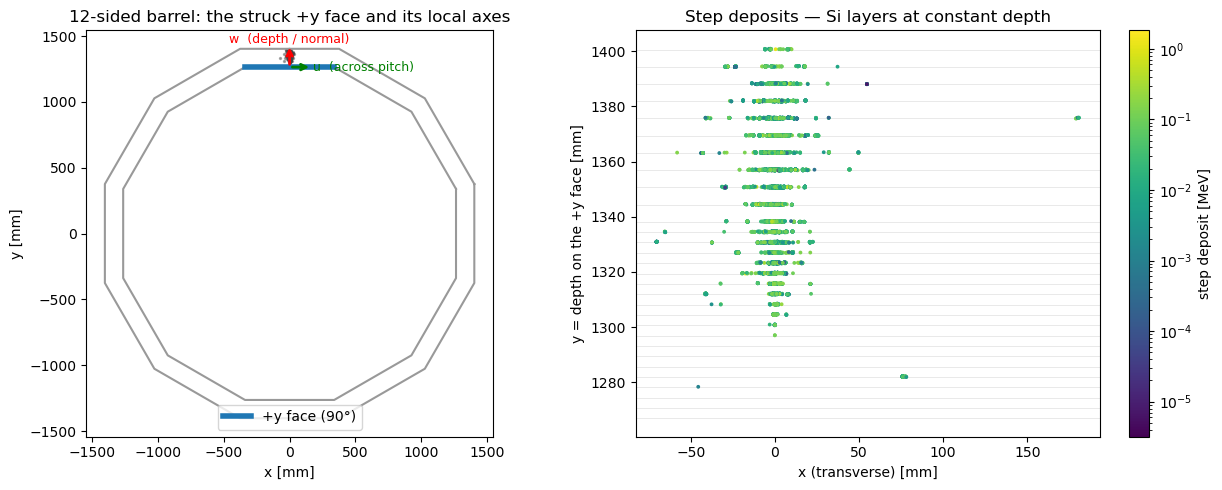

In [2]:
# per-step local-frame quantities, exactly as the converter computes them
centers = pc.si_layer_centers()                                   # 30 Si-layer depths (mm; perpendicular face distance)
phin_s = pc.face_phi(csx, csy)                                    # per-step face normal azimuth
u_s, v_s, w_s = pc.to_local(csx, csy, csz, phin_s)               # local: u across-pitch, v along-z, w depth
layer_s = np.argmin(np.abs(w_s[:, None] - centers[None, :]), axis=1)   # layer by DEPTH (see sec 5)

# The recorded Geant4 step position sits a constant ~0.1 mm into the silicon vs the geometric
# model centre (a step-position convention). It does not affect layer assignment (nearest centre,
# layers are ~4 mm apart), but for depth plots we reference the MEASURED sensor mid-plane per layer.
Z0 = float(np.median(w_s - centers[layer_s]))
cen_data = centers.copy()
for L in np.unique(layer_s):
    cen_data[L] = np.median(w_s[layer_s == L])
print(f"model-vs-recorded depth offset Z0 = {Z0*1000:.0f} um (constant; referenced out below)")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# (a) 12-gon schematic with the +y face and the local axes
Rin = pc.ECAL_RMIN_MM / np.cos(np.radians(15)); Rout = pc.ECAL_RMAX_MM / np.cos(np.radians(15))
vang = np.radians(np.arange(15, 376, 30))
ax[0].plot(Rin*np.cos(vang), Rin*np.sin(vang), color="0.6"); ax[0].plot(Rout*np.cos(vang), Rout*np.sin(vang), color="0.6")
xf = pc.ECAL_RMIN_MM * np.tan(np.radians(15)); r0 = pc.ECAL_RMIN_MM
ax[0].plot([-xf, xf], [r0, r0], color="#1f77b4", lw=4, label="+y face (90°)")
ax[0].annotate("", xy=(0, r0+170), xytext=(0, r0), arrowprops=dict(arrowstyle="->", color="r", lw=2))
ax[0].annotate("", xy=(170, r0), xytext=(0, r0), arrowprops=dict(arrowstyle="->", color="g", lw=2))
ax[0].text(0, r0+185, "w  (depth / normal)", color="r", ha="center", fontsize=9)
ax[0].text(180, r0, "u  (across pitch)", color="g", va="center", fontsize=9)
ax[0].scatter(csx[::25], csy[::25], s=2, color="#444", alpha=0.4, zorder=0)
ax[0].set_aspect("equal"); ax[0].set_xlabel("x [mm]"); ax[0].set_ylabel("y [mm]")
ax[0].set_title("12-sided barrel: the struck +y face and its local axes"); ax[0].legend(loc="lower center")
# (b) the steps on that face: layers sit at constant depth (horizontal lines)
sc = ax[1].scatter(csx, csy, s=3, c=cE*1e3, cmap="viridis", norm=LogNorm())
for c in centers: ax[1].axhline(c, color="0.85", lw=0.4, zorder=0)
ax[1].set_xlabel("x (transverse) [mm]"); ax[1].set_ylabel("y = depth on the +y face [mm]")
ax[1].set_title("Step deposits — Si layers at constant depth"); plt.colorbar(sc, ax=ax[1], label="step deposit [MeV]")
plt.tight_layout(); plt.show()

## 4. Detailed mode resolves position *inside* each 320 µm sensor

The payoff of detailed mode: each step is localized **within** the silicon, not just attributed
to a pixel. The left panel shows every step's depth relative to the **sensor mid-plane** — the
deposits sit inside the ±0.16 mm (320 µm) silicon, exactly as they should. (Geant4 records the
step position a constant ~0.1 mm into the sensor versus the bare geometric layer centre — a
step-position convention, printed as `Z0` above; it is referenced out here and does not affect
which layer a step is assigned to.) The right panel makes the "one or several steps per crossing"
point from §3 concrete: it counts the Geant4 steps in each crossing. It peaks at **one step** — a
fast particle pierces the thin sensor in a single increment — with a tail to several (slower,
steeper, or scattered tracks). This is not bookkeeping trivia: a crossing's direction is measured
from the displacement between its **first and last** step, so a single-step crossing has no
internal lever arm and must take its direction from the producing particle's momentum instead
(§6).

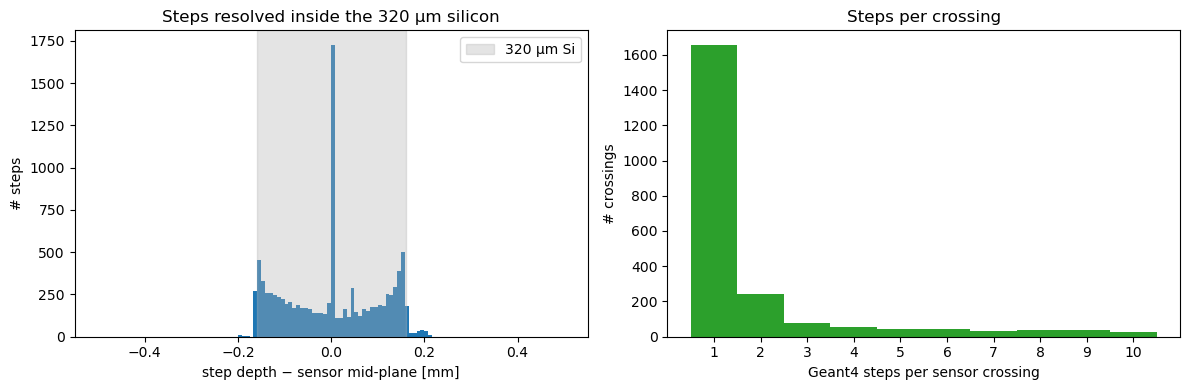

built 2,535 per-sensor charged-track crossings; stats: {'neutral_groups_skipped': 24, 'dir_from_momentum': 1672}


In [3]:
segs, stats = pc.build_segments_A(d)   # the per-sensor crossings (the payload)
ns = np.array([s["n_steps"] for s in segs])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
resid_step = w_s - cen_data[layer_s]
ax[0].hist(resid_step, bins=120, range=(-0.5, 0.5), color="#1f77b4")
ax[0].axvspan(-pc.SI_THICK_MM/2, pc.SI_THICK_MM/2, color="0.7", alpha=0.35, label="320 µm Si")
ax[0].set_xlabel("step depth − sensor mid-plane [mm]"); ax[0].set_ylabel("# steps")
ax[0].set_title("Steps resolved inside the 320 µm silicon"); ax[0].legend()
ax[1].hist(ns, bins=np.arange(1, 12)-0.5, color="#2ca02c")
ax[1].set_xlabel("Geant4 steps per sensor crossing"); ax[1].set_ylabel("# crossings")
ax[1].set_title("Steps per crossing"); ax[1].set_xticks(range(1, 11))
plt.tight_layout(); plt.show()
print(f"built {len(segs):,} per-sensor charged-track crossings; stats: {stats}")

## 5. Two geometry choices, justified by the data

**Why the layer label matters — what it is used for.** Every crossing must be tagged with *which*
of the 30 sensors it happened in, and that label is load-bearing twice over. First, PIXELAV is run
**per sensor**: each layer can have its own thickness, bias, field map and Stage-A configuration,
so a crossing sent to the wrong layer would be simulated with the wrong sensor model. Second, our
local geometry — the entry depth, the front/back face, and therefore the entry point and direction
we hand over — is measured *relative to that layer's position*, so a wrong label also corrupts the
kinematics. (The label additionally builds the longitudinal shower profile, §7d.) A label error is
not cosmetic: it routes a track to the wrong detector. The two choices below are exactly where that
label is easy to get subtly wrong, so the data has to settle them.

Two reconstruction choices are easy to get subtly wrong; the data settles both.

**(a) Where is the face?** The dodecagon could be oriented with a face *centre* or a *vertex* at
+y. The step-azimuth distribution peaks sharply at **90°**, so the +y beam strikes a face
*centre* there: face centres sit at `k·30°` (i.e. `FACE_PHI0 = 0`, not the 15° offset one might
assume from the geometry's 15° rotation). Getting this wrong by 15° throws the local entry point
off by `r·sin15° ≈ 300 mm`.

**(b) What labels a layer — radius or depth?** The sensors are **flat**, so a layer sits at
constant **depth** `w` (perpendicular distance to the face), *not* constant radius
`r = √(x²+y²)`. For an off-axis step (x up to ~180 mm here) `r` runs up to ~12 mm larger than
`w`, so assigning the layer by radius mislabels the wide-shower steps into the wrong (deeper)
layer. Assigning by **depth** keeps every step within ~0.26 mm of its geometric layer centre
(sub-millimetre; ≲ 0.2 mm once the step-position offset of §4 is referenced out, see §8). The
right panel shows both — radius-based assignment has a fat mislabelling tail; depth-based is tight.

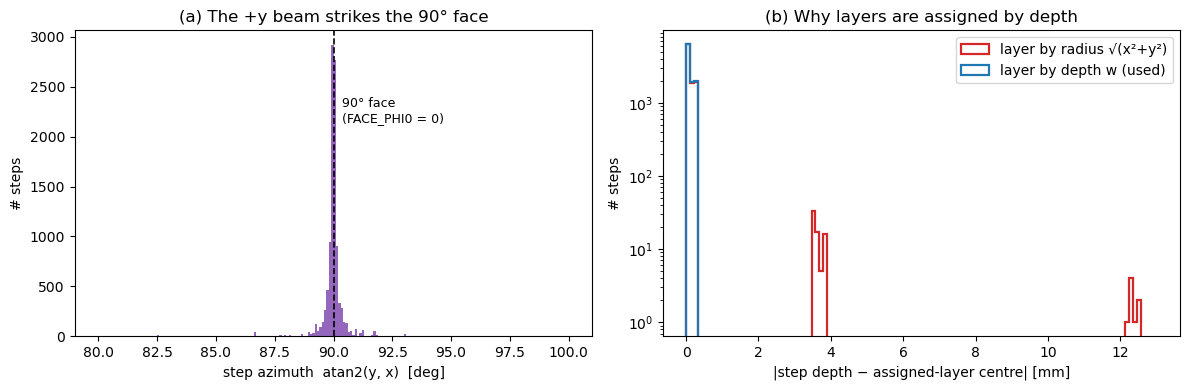

depth residual: by-radius max = 12.5 mm | by-depth max = 0.26 mm


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# (a) step azimuth -> the face is at 90 deg
phi_deg = np.degrees(np.arctan2(csy, csx))
ax[0].hist(phi_deg, bins=200, range=(80, 100), color="#9467bd")
ax[0].axvline(90, ls="--", color="k", lw=1.2)
ax[0].text(90.2, ax[0].get_ylim()[1]*0.7, " 90° face\n (FACE_PHI0 = 0)", fontsize=9)
ax[0].set_xlabel("step azimuth  atan2(y, x)  [deg]"); ax[0].set_ylabel("# steps")
ax[0].set_title("(a) The +y beam strikes the 90° face")
# (b) depth residual: layer-by-radius (wrong) vs layer-by-depth (used)
r_s = np.sqrt(csx**2 + csy**2)
lay_by_r = np.argmin(np.abs(r_s[:, None] - centers[None, :]), axis=1)
resid_if_r = np.abs(w_s - centers[lay_by_r])     # depth residual if layer assigned by radius
resid_w    = np.abs(w_s - centers[layer_s])      # depth residual with depth-based assignment
ax[1].hist(resid_if_r, bins=120, range=(0, 13), histtype="step", lw=1.6, color="#d62728", label="layer by radius √(x²+y²)")
ax[1].hist(resid_w,    bins=120, range=(0, 13), histtype="step", lw=1.6, color="#1f77b4", label="layer by depth w (used)")
ax[1].set_yscale("log"); ax[1].set_xlabel("|step depth − assigned-layer centre| [mm]"); ax[1].set_ylabel("# steps")
ax[1].set_title("(b) Why layers are assigned by depth"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"depth residual: by-radius max = {resid_if_r.max():.1f} mm | by-depth max = {resid_w.max():.2f} mm")

## 6. From steps to crossings — the reconstruction

For each `(MCParticle, face)` the converter **time-orders** the steps and splits them into
maximal **runs of constant layer**: each run is one sensor crossing. Within a run:
- the **entry point** is the *earliest-in-time* step (the face the track actually enters);
- the **direction** is the entry→exit displacement **in time order** — which is correct for
  *both* inward- and outward-going tracks (a backscattered electron moving toward smaller radius
  gets the right sign), and robust to scattering/curvature. A single-step crossing has no
  displacement, so its direction falls back to the producing particle's momentum.

Time-ordering matters: using the radial min→max step instead would always point *outward* and
**flip the cot signs for every inward-going (backscattered) track**.

**How to read the two panels:**

*Left — one particle threading the detector.* Each dot is a single step (an energy deposit),
coloured by time; the open black circles mark where each per-sensor crossing **begins** (its entry
step). This is one charged particle moving outward through the layers, depositing as it goes — literally what "one track → several sensor crossings" looks like. The crossings fall one-per-layer along a smooth, roughly straight trajectory,
exactly as a real track through a layered detector must.

*Right — two crossings up close, in the sensor's own frame.* The axes are `u` (across the pixel
pitch) and depth `w` through the 320 µm silicon (grey band); the ★ marks the entry. The **red
curve** is a *soft* crossing: its several steps trace an angled path from one face to the other, so
its direction is taken from the entry→exit displacement (this one even enters from the *back* face
— an inward-going track — which time-ordering handles correctly). The **blue arrow** is a *hard*
crossing: a single step, so there is no internal path to measure and the direction comes from the
particle's momentum, drawn as the straight line PIXELAV will transport across the depth — here
essentially perpendicular (cot ≈ 0). The reconstruction returns exactly what the physics demands: a perpendicular hard track and a wide-angle soft one, each with a
well-defined entry on a sensor face — i.e. a sensible PIXELAV record.

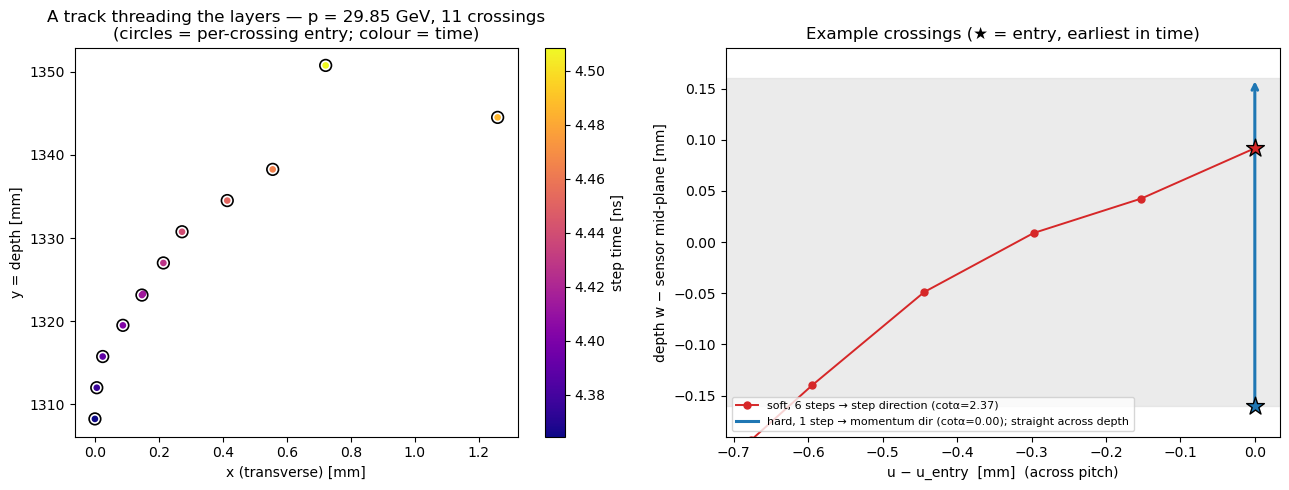

most-threading track 4964: p = 29.85 GeV, crosses 11 sensors


In [5]:
from collections import Counter
def crossing_steps(tid, lay):
    idx = np.where((cmc == tid) & (layer_s == lay))[0]
    return idx[np.argsort(ct[idx])]   # time-ordered

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# left: the track that crosses the most sensors -- a clean "threading" example
tid_best = Counter(s["track_id"] for s in segs).most_common(1)[0][0]
mB = np.where(cmc == tid_best)[0]; segB = [s for s in segs if s["track_id"] == tid_best]
sc = ax[0].scatter(csx[mB], csy[mB], c=ct[mB], s=14, cmap="plasma")
for s in segB:
    ix = crossing_steps(tid_best, s["layer_id"])[0]
    ax[0].scatter(csx[ix], csy[ix], s=70, facecolors="none", edgecolors="k", lw=1.2, zorder=5)
ax[0].set_xlabel("x (transverse) [mm]"); ax[0].set_ylabel("y = depth [mm]")
ax[0].set_title(f"A track threading the layers — p = {segB[0]['p_GeV']:.2f} GeV, {len(segB)} crossings\n"
               f"(circles = per-crossing entry; colour = time)")
plt.colorbar(sc, ax=ax[0], label="step time [ns]")

# right: the two direction modes, in the local (u, w) frame
soft = [s for s in segs if s["p_GeV"] < 0.05 and s["n_steps"] >= 4]
hard1 = [s for s in segs if s["p_GeV"] > 1 and "dir_from_momentum" in s["flags"]]
if soft:                                    # multi-step: direction from the step displacement
    s = soft[0]; ix = crossing_steps(s["track_id"], s["layer_id"])
    uu = u_s[ix] - u_s[ix][0]; ww = w_s[ix] - cen_data[s["layer_id"]]
    ax[1].plot(uu, ww, "o-", color="#d62728", lw=1.4, ms=5,
               label=f"soft, {s['n_steps']} steps → step direction (cotα={s['cot_alpha']:.2f})")
    ax[1].scatter(uu[0], ww[0], marker="*", s=180, color="#d62728", edgecolor="k", zorder=6)
if hard1:                                   # single-step: PIXELAV transports the straight track itself
    s = hard1[0]; ca_h = s["cot_alpha"]; hw = pc.SI_THICK_MM/2
    ax[1].annotate("", xy=(ca_h*pc.SI_THICK_MM, hw), xytext=(0, -hw),
                   arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=2.2))
    ax[1].scatter(0, -hw, marker="*", s=180, color="#1f77b4", edgecolor="k", zorder=6)
    ax[1].plot([], [], color="#1f77b4", lw=2.2,
               label=f"hard, 1 step → momentum dir (cotα={ca_h:.2f}); straight across depth")
ax[1].axhspan(-pc.SI_THICK_MM/2, pc.SI_THICK_MM/2, color="0.85", alpha=0.5, zorder=0)
ax[1].set_ylim(-0.19, 0.19)
ax[1].set_xlabel("u − u_entry  [mm]  (across pitch)"); ax[1].set_ylabel("depth w − sensor mid-plane [mm]")
ax[1].set_title("Example crossings (★ = entry, earliest in time)"); ax[1].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()
print(f"most-threading track {tid_best}: p = {segB[0]['p_GeV']:.2f} GeV, crosses {len(segB)} sensors")

## 7. The payload — the per-sensor PIXELAV records

The result is one record per crossing with everything Stage B needs. Reading the four panels:

**(a) Local entry points** — *where on the sensor face* each crossing enters, pooled over **all
30 layers** (every crossing referenced to the same local origin). These are **face** coordinates
measured from the **detector axis** — `u` along the across-pitch direction, `v` along cylinder-z,
with **(0,0) the +y beam axis** — *not* within-a-pixel coordinates. A sensor face is the whole
30° wedge (hundreds of mm across in `u`, the full barrel length in `v`), so the ±tens-of-mm spread
is the **shower's transverse footprint** (a tight core at the axis + a diffuse halo), and has
nothing to do with the 100 µm pitch or the 320 µm depth. The pitch is the *granularity* within
this plane (far finer than a dot); the depth is a separate axis `w` (shown in §6-right and §8.1,
where the ranges are correctly sub-mm).

There are really **two** notions of "position" to keep separate, and PIXELAV treats them very
differently. The **absolute** spot on the wedge (which sensor, where on the face) it ignores
entirely — it only ever simulates a small patch of pixels around the impact, so the global
location is irrelevant. The **sub-pixel** position (where *within* a pixel the track crosses) it
cares about a great deal — charge sharing and cluster shape depend strongly on it — but it
**supplies that itself**, sampling it at random over the central 3×3 pixels, because PIXELAV's
standard job is to *scan* the position dependence and build a **template** (the map of
cluster-shape-versus-position later used to reconstruct a hit). So from us PIXELAV reads only the
**direction, momentum and type**; the entry points plotted here ride along as labels. (To make
PIXELAV use *our* real sub-pixel entry — the cluster of one specific crossing rather than a
template — we patch its wrapper; see §1.)

**(b) Direction vs momentum** — `cot α` (the track's slope across the pitch) split into three
momentum bands. Hard tracks (blue) pile up sharply at `cot α ≈ 0` — they cross nearly
perpendicular; soft tracks (red) are broad — they arrive at all angles. The expected EM-shower
behaviour.

**(c) Crossing-momentum spectrum — why it peaks.** It rises to ~10–40 MeV, then
falls. The rise is *not* present in the particle spectrum (which keeps climbing toward low
momentum); it is a **penetration effect**. The shower's tens of thousands of sub-MeV particles
are born inside the dense tungsten and have a range of microns — they are absorbed before they
ever reach a silicon sensor, so they make almost no crossings (in this event ≈36,000 sub-MeV
charged particles produce only ~270 crossings). Only particles energetic enough to escape the
tungsten and reach the silicon register crossings, and harder ones cross more layers each (median
~1 sensor below 1 MeV → ~5 above 1 GeV). The steeply falling production spectrum **times** this
rising reach-and-multiplicity gives a peak at the momentum where particles are both numerous *and*
able to cross sensors.

**(d) Crossings per layer** — the number of charged-track crossings in each of the 30 silicon
layers (0 = front). It rises from the front, peaks around layer ~20, then falls: the classic
**longitudinal shower profile** (the same shape as the energy profile in notebook 04, but counted
in track crossings) — few crossings where the shower is just starting, a maximum at shower max,
then the dying tail.

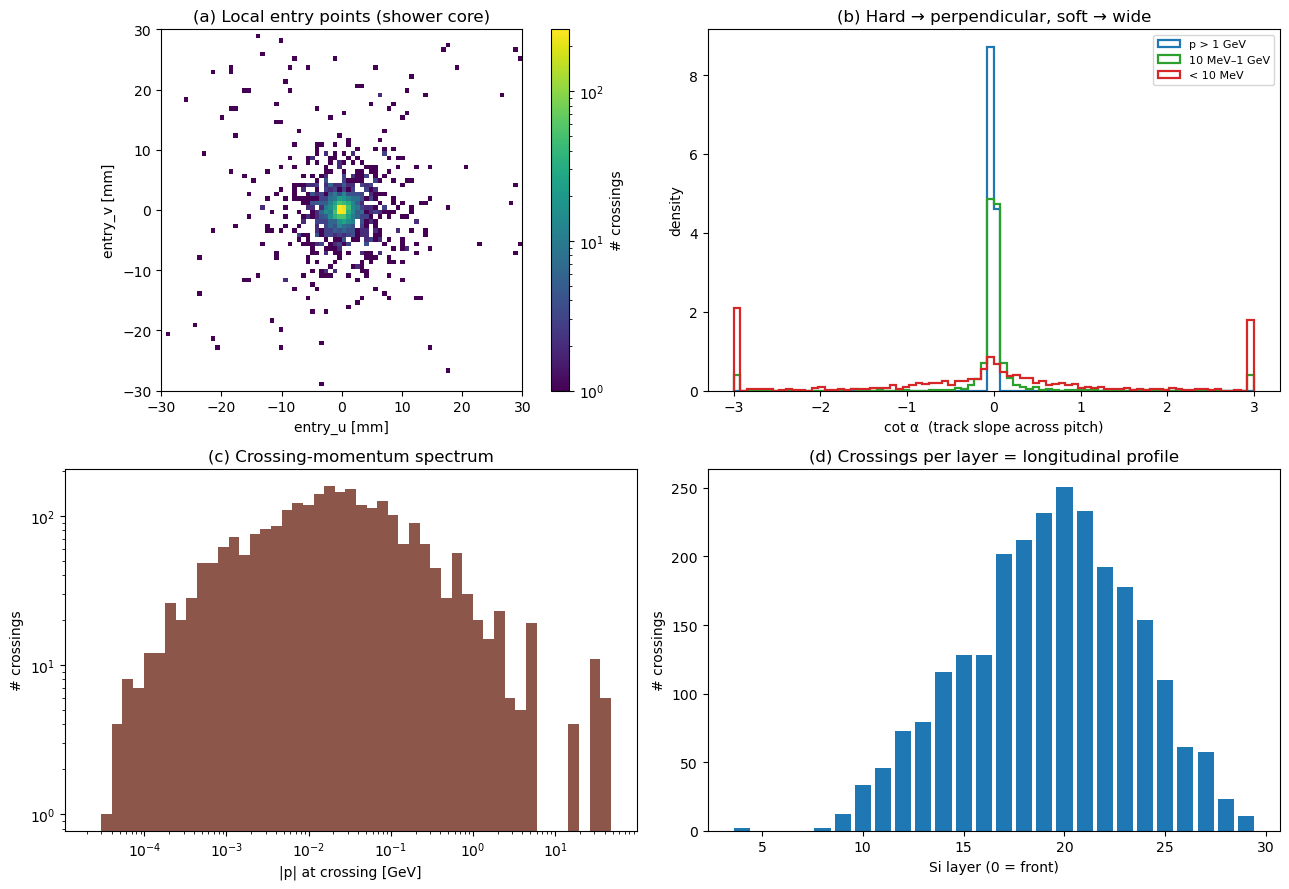

entry_u/v median = (-0.01, -0.01) mm; 95% within (10.0, 10.3) mm
median |cot α|: p>1 GeV = 0.0010  |  p<10 MeV = 0.772


In [6]:
eu = np.array([s["entry_u"] for s in segs]); ev = np.array([s["entry_v"] for s in segs])
ca = np.array([s["cot_alpha"] for s in segs]); cb = np.array([s["cot_beta"] for s in segs])
pp = np.array([s["p_GeV"] for s in segs]);     ll = np.array([s["layer_id"] for s in segs])
fa = np.isfinite(ca)

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
# (a) entry points
h = ax[0,0].hist2d(eu, ev, bins=80, range=[[-30, 30], [-30, 30]], cmap="viridis", norm=LogNorm())
ax[0,0].set_xlabel("entry_u [mm]"); ax[0,0].set_ylabel("entry_v [mm]"); ax[0,0].set_aspect("equal")
ax[0,0].set_title("(a) Local entry points (shower core)"); plt.colorbar(h[3], ax=ax[0,0], label="# crossings")
# (b) cot alpha by momentum band
for sel, lab, col in [(pp > 1, "p > 1 GeV", "#1f77b4"), ((pp > 0.01) & (pp <= 1), "10 MeV–1 GeV", "#2ca02c"),
                      (pp <= 0.01, "< 10 MeV", "#d62728")]:
    s = sel & fa
    if s.any(): ax[0,1].hist(np.clip(ca[s], -3, 3), bins=80, range=(-3, 3), histtype="step", lw=1.6, color=col, label=lab, density=True)
ax[0,1].set_xlabel("cot α  (track slope across pitch)"); ax[0,1].set_ylabel("density")
ax[0,1].set_title("(b) Hard → perpendicular, soft → wide"); ax[0,1].legend(fontsize=8)
# (c) momentum spectrum
ax[1,0].hist(pp[pp > 0], bins=np.logspace(np.log10(pp[pp>0].min()), np.log10(pp.max()), 50), color="#8c564b")
ax[1,0].set_xscale("log"); ax[1,0].set_yscale("log"); ax[1,0].set_xlabel("|p| at crossing [GeV]")
ax[1,0].set_ylabel("# crossings"); ax[1,0].set_title("(c) Crossing-momentum spectrum")
# (d) crossings per layer
Ls, cs = np.unique(ll, return_counts=True)
ax[1,1].bar(Ls, cs, color="#1f77b4"); ax[1,1].set_xlabel("Si layer (0 = front)"); ax[1,1].set_ylabel("# crossings")
ax[1,1].set_title("(d) Crossings per layer = longitudinal profile")
plt.tight_layout(); plt.show()
print(f"entry_u/v median = ({np.median(eu):.2f}, {np.median(ev):.2f}) mm; 95% within "
      f"({np.percentile(np.abs(eu),95):.1f}, {np.percentile(np.abs(ev),95):.1f}) mm")
print(f"median |cot α|: p>1 GeV = {np.median(np.abs(ca[(pp>1)&fa])):.4f}  |  p<10 MeV = {np.median(np.abs(ca[(pp<0.01)&fa])):.3f}")

## 8. Validation — does the per-crossing table hold up?

These two plots are **sanity checks**, not new physics — they confirm the per-crossing records
are internally consistent. They are easy to misread, so, explicitly:

**(1) Entry depth inside the sensor.** For each crossing we take its recorded entry depth and
subtract the *measured* mid-plane of the sensor it was assigned to; the result should be small,
because an entry sits on a face — at most half the 320 µm thickness (0.16 mm, the dashed line)
from the mid-plane. The expected shape is a tall spike near zero with everything to the left of the dashed line: most crossings are single-step (recorded essentially at the mid-plane → residual ≈ 0), and the rest
enter at a face (≈ 0.16 mm). It says every crossing really does sit inside the 320 µm sensor it
was labelled with — the layer label and the local depth agree.

**(2) Hard → collimated, soft → wide.** A 2-D density of each crossing's direction steepness,
`|cot| = √(cot α² + cot β²)`, versus its momentum, with the median in cyan. It restates panel
7(b) across the full momentum range: at high `|p|` (right) the density and the median collapse to
`|cot| ≈ 0` (perpendicular); toward low `|p|` they fan out to large angles. The sparse upper-left
is simply that few crossings are both very soft *and* very steep. Again a consistency check — a
crossing's angle is set almost entirely by the particle's momentum, as it must be.

The cell also prints the **inward vs outward** split: a real fraction of crossings are
inward-going (backscattered tracks heading to smaller radius), and time-ordering gives them the
correct `cot` sign — a radial min→max scheme would have silently flipped it.

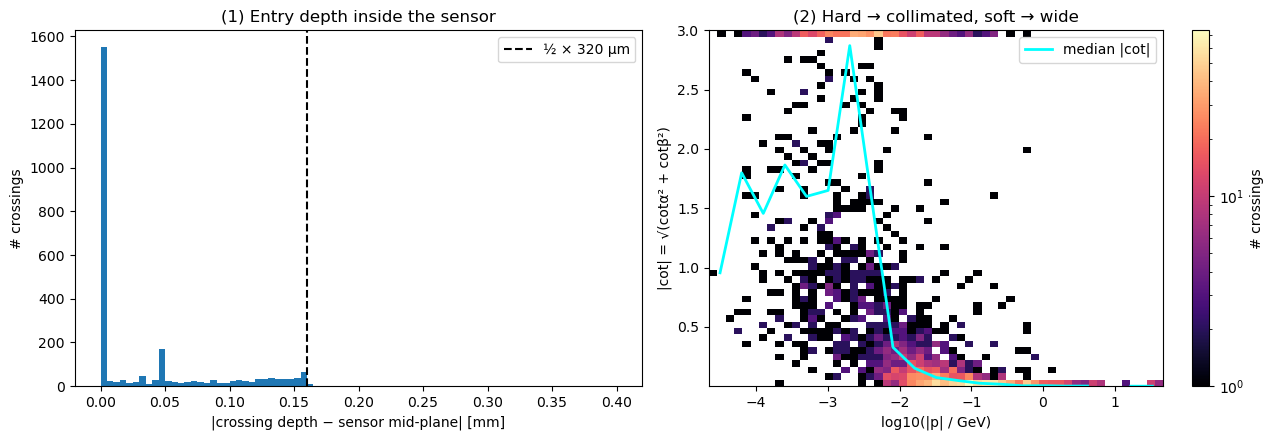

depth residual: median = 0.000 mm, max = 0.210 mm (≲ ½ Si thickness; entry at the face)
multi-step crossings: 626 outward, 253 inward — both get the correct cot sign via time order


In [7]:
# (1) depth residual per crossing; (2) |cot| vs |p| map
dw = np.array([s["depth_w_mm"] for s in segs]); resid = np.abs(dw - cen_data[ll])
cot_mag = np.hypot(np.clip(ca, -50, 50), np.clip(cb, -50, 50))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(resid, bins=80, range=(0, 0.4), color="#1f77b4")
ax[0].axvline(pc.SI_THICK_MM/2, ls="--", color="k", label="½ × 320 µm")
ax[0].set_xlabel("|crossing depth − sensor mid-plane| [mm]"); ax[0].set_ylabel("# crossings")
ax[0].set_title("(1) Entry depth inside the sensor"); ax[0].legend()
sel = fa & (pp > 0)
le = np.log10(np.clip(pp[sel], 1e-5, None))
hh = ax[1].hist2d(le, np.clip(cot_mag[sel], 0, 3), bins=[55, 55], cmap="magma", norm=LogNorm())
xb = np.linspace(le.min(), le.max(), 22); xc = 0.5*(xb[:-1]+xb[1:])
medc = [np.median(cot_mag[sel][(le >= lo) & (le < hi)]) if ((le >= lo) & (le < hi)).any() else np.nan
        for lo, hi in zip(xb[:-1], xb[1:])]
ax[1].plot(xc, medc, color="cyan", lw=2, label="median |cot|")
ax[1].set_xlabel("log10(|p| / GeV)"); ax[1].set_ylabel("|cot| = √(cotα² + cotβ²)")
ax[1].set_title("(2) Hard → collimated, soft → wide"); ax[1].legend()
plt.colorbar(hh[3], ax=ax[1], label="# crossings")
plt.tight_layout(); plt.show()

# (3) inward-going crossings (multi-step, so direction comes from the step displacement)
inward = 0; outward = 0
for s in segs:
    ix = crossing_steps(s["track_id"], s["layer_id"])
    if len(ix) >= 2:
        if (w_s[ix[-1]] - w_s[ix[0]]) < 0: inward += 1
        else: outward += 1
print(f"depth residual: median = {np.median(resid):.3f} mm, max = {resid.max():.3f} mm (≲ ½ Si thickness; entry at the face)")
print(f"multi-step crossings: {outward} outward, {inward} inward — both get the correct cot sign via time order")

## Summary & what's next

- **The per-sensor PIXELAV input is produced programmatically** from the simulation:
  `enableDetailedShowerMode` surfaces the Geant4 step truth on the EDM4hep path, and
  `pixelav_converter.py` reshapes it into **2,535 charged-track crossings** for this 50 GeV
  event — each with a local entry point, `cot α`/`cot β`, `|p|` and particle type.
- **The reconstruction choices are validated against the data:** the +y face at 90°, layers
  labelled by depth (not radius — radius mislabels off-axis steps by up to 12 mm, depth keeps every
  step in the right sensor), time-ordered entry/direction (correct for inward and outward tracks),
  and the expected hard-perpendicular / soft-wide angular behaviour.
- The intermediate table (`models/pixelav_segments_*.json` / `.csv`) is complete and in **mm**.

**Where our code ends and PIXELAV's setup begins** (full background + sources in
[`docs/pixelav_reference.md`](../docs/pixelav_reference.md)). PIXELAV's source is public
(`github.com/badeaa3/pixelav`; the Smart Pixels lineage `…/Muon_Collider_Smart_Pixels`), its
lengths are **microns**, and the Stage-B deck is a simple ASCII per-track list — so
`write_pixelav_deck()` now emits the **Smart Pixels 9-column** format (cot α, cot β, |p|,
flipped, entry labels, PID; `LENGTH_UNIT_MM = 1000`). What stays external:
1. **Stage A** — the per-sensor field/charge-transport model (E-field, bias, temperature,
   B-field, pitch). Hand-authored, or built from our TCAD via `CodexForster/TCADtoPixelAV`; not
   derived from this simulation.
2. **Two conventions to confirm against the binary:** stock PIXELAV **randomises the impact over
   the central 3×3 pixels**, so our precise entry point is carried as a label unless the wrapper
   is patched to inject it; and the cot α/β axis labelling differs between the public source
   copies, so the sign/axis should be checked with a one-track round-trip.

A known limitation of this calorimeter-readout method: the EDM4hep `CaloHitContribution` carries no per-step momentum, so each crossing inherits the producing particle's **production** momentum (fine for the hard, near-straight tracks that dominate; wrong for a particle that has radiated down to low energy by a deep layer). The companion method (05a) — [05a](05a_pixelav_inputs_tracker.ipynb), the tracker readout — resolves this with the true per-crossing momentum. This is a single 50 GeV event; the same pipeline runs unchanged over a multi-event sample.